In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.inspection import PartialDependenceDisplay

from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [2]:
kc_sales = pd.read_csv('../data/kc_house_data.csv')

X = kc_sales.drop(columns = ['id', 'date', 'price'])
y = kc_sales['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    random_state = 321
)

First, let's fit a decision tree model to the data.

In [3]:
ct = ColumnTransformer(
    transformers = [
        ('ohe', OneHotEncoder(), ['zipcode'])
    ],
    remainder='passthrough'
)

dt_pipe = Pipeline(
    steps = [
        ('transformer', ct),
        ('model', DecisionTreeRegressor())
    ]
).fit(X_train, y_train)

y_pred = dt_pipe.predict(X_test)

print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')
print(f'R2: {r2_score(y_test, y_pred)}')

MSE: 34681670867.19687
RMSE: 186230.15563328317
MAE: 99312.61381863047
MAPE: 0.1853384577236336
R2: 0.7379050502090787


# Part 1: Using the [plot_tree function](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html), draw the first 2 levels of the decision tree that the model above used. What features did it use?

Hint: You can extract out the decision tree from the above pipeline using the step name. You can also use the [get_feature_names_out method](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline.get_feature_names_out) in order to label the diagram.

Hint 2: To make the plot more readable, you may want to use the plt.subplots function to create an axis with a larger figsize.

## ANSWER: Grade, Latitude, Sqft Living

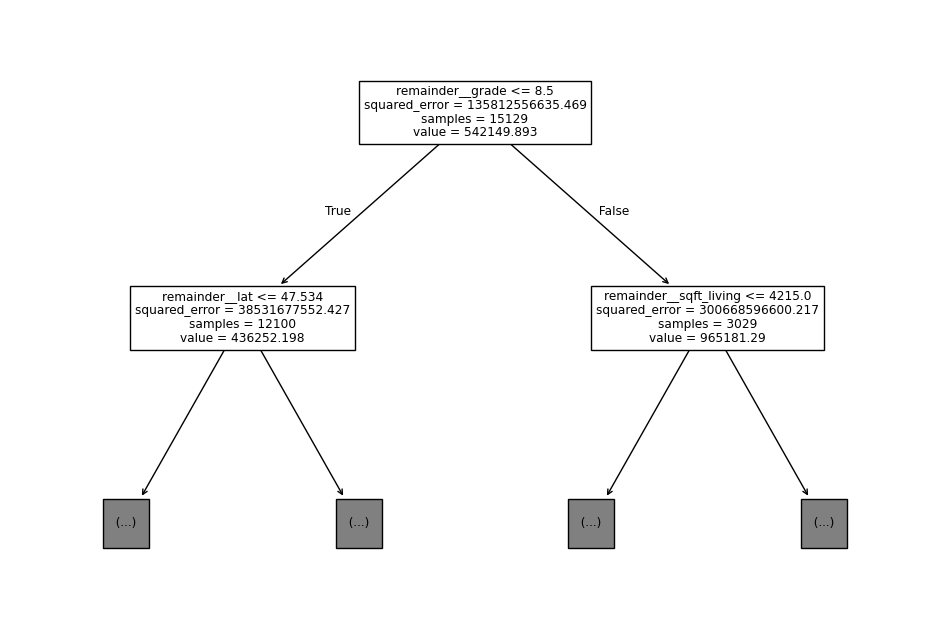

In [4]:
plt.subplots(figsize=(12, 8))

plot_tree(
    decision_tree=dt_pipe.named_steps['model'],
    max_depth=1,
    feature_names=dt_pipe[:-1].get_feature_names_out()
);

Now, let's see if a random forest model does any better.

In [5]:
ct = ColumnTransformer(
    transformers = [
        ('ohe', OneHotEncoder(), ['zipcode'])
    ],
    remainder='passthrough'
)

rf_pipe = Pipeline(
    steps = [
        ('transformer', ct),
        ('model', RandomForestRegressor())
    ]
).fit(X_train, y_train)

y_pred = rf_pipe.predict(X_test)

print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')
print(f'R2: {r2_score(y_test, y_pred)}')

MSE: 17384524195.29642
RMSE: 131850.38564712816
MAE: 67395.66614169678
MAPE: 0.1308209051228412
R2: 0.8686223621245749


## Part 2: Random forest models can assign a feature importance, which essentially tells what features the random forest tended to rely on when building out decision trees.

Which features had the highest feature importance for the random forest model?

Hint: You can get feature importances using the [feature_importances_ attribute](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor.feature_importances_). You may also want to use the get_feature_names_out method to see what variable each importance corresponds to.

## ANSWER: Grade, Latitude, Sqft Living

In [6]:
features_df = pd.DataFrame(
    data={
        'features': rf_pipe[:-1].get_feature_names_out(),
        'importance': rf_pipe.named_steps['model'].feature_importances_
    }
)
features_df.sort_values('importance', ascending=False).head(3)

,features,importance
78,remainder__grade,0.321853
72,remainder__sqft_living,0.247611
83,remainder__lat,0.164256


## Part 3: The feature importance scores tell us what features the model uses, but not how it uses them. 
To get an idea about how a particular feature affects the predicted sales price, we can use a [partial dependence plot](https://christophm.github.io/interpretable-ml-book/pdp.html).

Use the [PartialDependenceDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.PartialDependenceDisplay.html) to create a partial dependence plot for the random forest model to see how grade affects the predicted sales price. Create another to see how latitude affects the predicted sales price. 

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 8 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


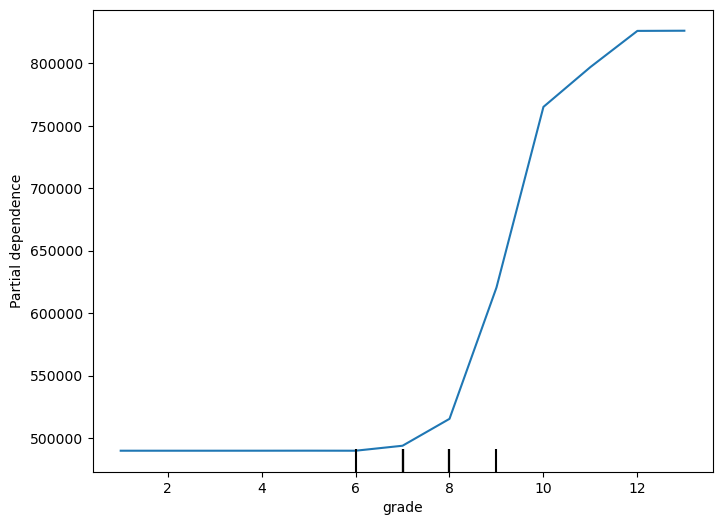

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    estimator=rf_pipe,
    X=X,
    features=['grade'],
    ax=ax
);

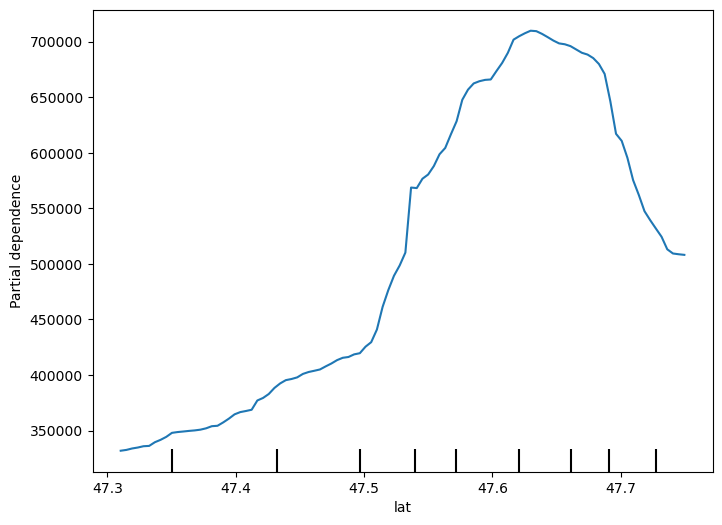

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    estimator=rf_pipe,
    X=X,
    features=['lat'],
    ax=ax
);

Finally, let's look at a gradient boosting model.

In [9]:
ct = ColumnTransformer(
    transformers = [
        ('ohe', OneHotEncoder(), ['zipcode'])
    ],
    remainder='passthrough'
)

gb_pipe = Pipeline(
    steps = [
        ('transformer', ct),
        ('model', GradientBoostingRegressor())
    ]
).fit(X_train, y_train)

y_pred = gb_pipe.predict(X_test)

print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')
print(f'R2: {r2_score(y_test, y_pred)}')

MSE: 19217194430.30876
RMSE: 138626.0957767648
MAE: 74610.19718908807
MAPE: 0.14805247094069507
R2: 0.8547725791926


## Part 4: How does the performance on the test set change when you increase the number of estimators (the number of boosting steps) from the default of 100 to 1000?

## ANSWER: The R2 increases and the MAE decreases.

In [10]:
gb_pipe = Pipeline(
    steps = [
        ('transformer', ct),
        ('model', GradientBoostingRegressor(n_estimators=1000))
    ]
).fit(X_train, y_train)

y_pred = gb_pipe.predict(X_test)

print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')
print(f'R2: {r2_score(y_test, y_pred)}')

MSE: 16910529915.146833
RMSE: 130040.49336705406
MAE: 64522.49949700862
MAPE: 0.1256502018613566
R2: 0.8722044129298172
